In [2]:
import os
import numpy as np
import pandas as pd
from datetime import datetime
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import os, platform
 
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
 
BATTERY_COLORS = {
    'B0005':'#378ADD','B0006':'#1D9E75',
    'B0007':'#D85A30','B0018':'#8B5CF6',
}
GROUP_COLORS = {
    'A':'#1D9E75','C':'#F59E0B',
    'F':'#E24B4A','G':'#A32D2D',
}
base_path = 'data/new_data'

In [6]:
df_A       = pd.read_csv(os.path.join(base_path, 'df_A_main.csv'))
df_anomaly = pd.read_csv(os.path.join(base_path, 'df_anomaly.csv'))
df_imp_A   = pd.read_csv(os.path.join(base_path, 'df_imp_A_main.csv'))
 
df_A_valid = df_A[df_A['cap_flag'] == 'valid'].copy()
 
# impedance 순번 및 사이클 매핑
df_imp_A = df_imp_A.sort_values(['battery_id','test_id'])
df_imp_A['imp_cycle_no'] = df_imp_A.groupby('battery_id').cumcount() + 1
df_imp_A['discharge_cycle_no'] = ((df_imp_A['imp_cycle_no'] + 1) // 2)
 
imp_agg = (
    df_imp_A.groupby(['battery_id','discharge_cycle_no'])[['Re','Rct']]
    .mean().reset_index()
    .rename(columns={'Re':'Re_val','Rct':'Rct_val'})
)
 
df_A_merged = df_A_valid.merge(imp_agg, on=['battery_id','discharge_cycle_no'], how='left')
 
print("=" * 55)
print("데이터 로드 완료")
print("=" * 55)
print(f"df_A_merged: {len(df_A_merged)}행  Re_val 유효: {df_A_merged['Re_val'].notna().sum()}행")

데이터 로드 완료
df_A_merged: 636행  Re_val 유효: 444행



[2] Re 조기 경보 시점 분석
B0005: EOL=107사이클 | Re경보=55 (EOL보다 52사이클 먼저) | Rct경보=103
B0006: EOL=61사이클 | Re경보=86 (EOL보다 -25사이클 먼저) | Rct경보=97
B0007: EOL=125사이클 | Re경보=27 (EOL보다 98사이클 먼저) | Rct경보=97
B0018: EOL=nan사이클 | Re경보=nan (EOL보다 nan사이클 먼저) | Rct경보=nan

Re  평균 선행 사이클: 41.7사이클
Rct 평균 선행 사이클: -1.3사이클


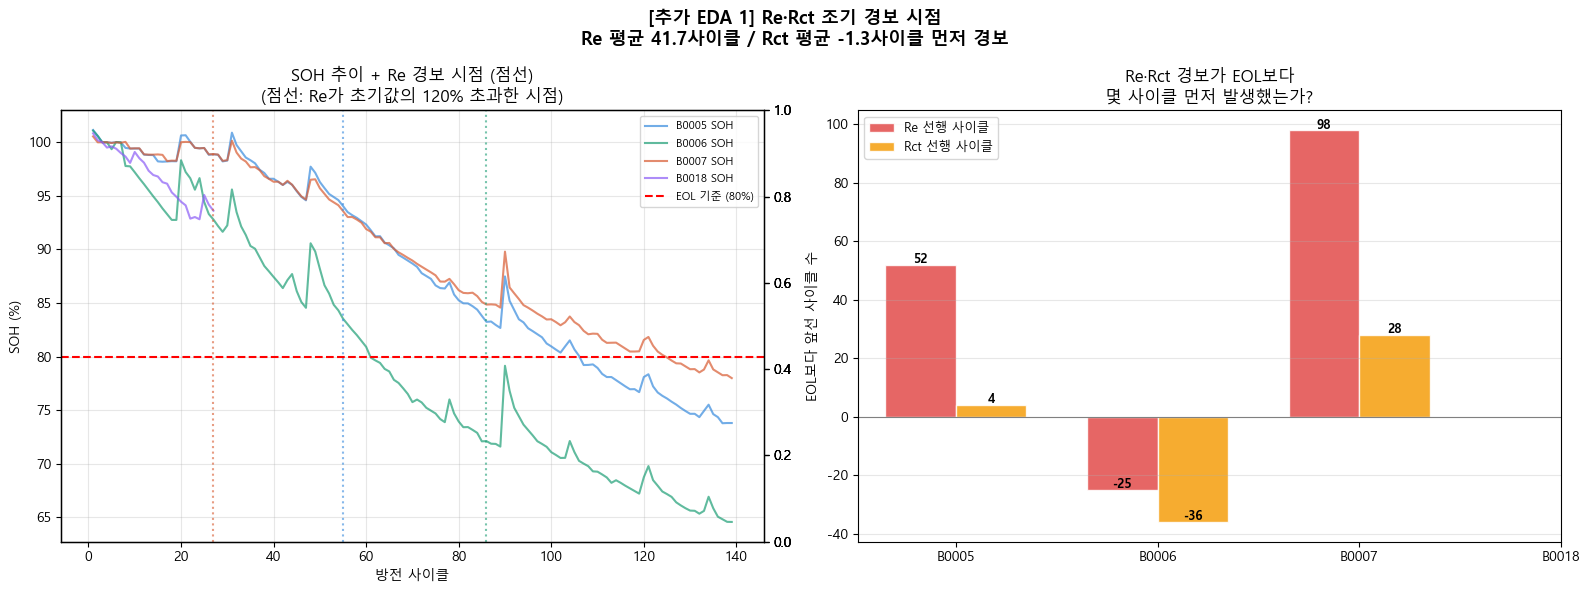

[저장] extra_eda1_early_warning.png


In [7]:
print("\n" + "=" * 55)
print("[2] Re 조기 경보 시점 분석")
print("=" * 55)
 
# EOL 기준: SOH 80%
# Re 경보 기준: 배터리별 초기 Re 평균의 120% 초과 (20% 이상 증가)
early_warning = []
 
for bid in sorted(df_A_merged['battery_id'].unique()):
    b = df_A_merged[df_A_merged['battery_id']==bid].dropna(subset=['Re_val'])
 
    # EOL 시점
    eol_cycle = b[b['SOH'] < 80]['discharge_cycle_no'].min()
 
    # Re 초기값 (앞 10개 평균)
    re_init = b['Re_val'].head(10).mean()
 
    # Re 경보 시점: 초기값의 120% 초과 첫 사이클
    re_warn_cycle = b[b['Re_val'] > re_init * 1.2]['discharge_cycle_no'].min()
 
    # Rct 경보 시점
    rct_init = b['Rct_val'].head(10).mean()
    rct_warn_cycle = b[b['Rct_val'] > rct_init * 1.2]['discharge_cycle_no'].min()
 
    lead_re  = eol_cycle - re_warn_cycle  if pd.notna(re_warn_cycle)  else np.nan
    lead_rct = eol_cycle - rct_warn_cycle if pd.notna(rct_warn_cycle) else np.nan
 
    early_warning.append({
        'battery_id': bid,
        'eol_cycle': eol_cycle,
        're_warn_cycle': re_warn_cycle,
        'rct_warn_cycle': rct_warn_cycle,
        'lead_re': lead_re,
        'lead_rct': lead_rct,
    })
    print(f"{bid}: EOL={eol_cycle}사이클 | Re경보={re_warn_cycle:.0f} (EOL보다 {lead_re:.0f}사이클 먼저) | Rct경보={rct_warn_cycle:.0f}")
 
ew_df = pd.DataFrame(early_warning)
 
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# 왼쪽: SOH + Re 추이 (배터리 4개)
for bid in sorted(df_A_merged['battery_id'].unique()):
    b = df_A_merged[df_A_merged['battery_id']==bid].dropna(subset=['Re_val'])
    color = BATTERY_COLORS.get(bid, 'gray')
    ax1 = axes[0]
    ax2 = ax1.twinx() if bid == 'B0005' else axes[0].twinx()
 
    # Re 정규화 (0~1 스케일로 비교 용이하게)
    re_norm = (b['Re_val'] - b['Re_val'].min()) / (b['Re_val'].max() - b['Re_val'].min())
    soh_norm = (b['SOH'] - b['SOH'].min()) / (b['SOH'].max() - b['SOH'].min())
 
    axes[0].plot(b['discharge_cycle_no'], b['SOH'],
                 linewidth=1.5, color=color, alpha=0.7, label=f'{bid} SOH')
 
# Re 경보 시점 수직선
for _, row in ew_df.iterrows():
    color = BATTERY_COLORS.get(row['battery_id'], 'gray')
    if pd.notna(row['re_warn_cycle']):
        axes[0].axvline(x=row['re_warn_cycle'], color=color,
                        linestyle=':', linewidth=1.5, alpha=0.6)
 
axes[0].axhline(y=80, color='red', linestyle='--', linewidth=1.5,
                label='EOL 기준 (80%)')
axes[0].set_xlabel('방전 사이클')
axes[0].set_ylabel('SOH (%)')
axes[0].set_title('SOH 추이 + Re 경보 시점 (점선)\n(점선: Re가 초기값의 120% 초과한 시점)')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].grid(alpha=0.3)
 
# 오른쪽: 조기 경보 선행 사이클 수 바차트
x = range(len(ew_df))
width = 0.35
bars1 = axes[1].bar([i-width/2 for i in x], ew_df['lead_re'],
                    width=width, label='Re 선행 사이클',
                    color='#E24B4A', alpha=0.85, edgecolor='white')
bars2 = axes[1].bar([i+width/2 for i in x], ew_df['lead_rct'],
                    width=width, label='Rct 선행 사이클',
                    color='#F59E0B', alpha=0.85, edgecolor='white')
 
for bar, val in zip(bars1, ew_df['lead_re']):
    if pd.notna(val):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                     f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, ew_df['lead_rct']):
    if pd.notna(val):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                     f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')
 
axes[1].axhline(y=0, color='gray', linewidth=0.8)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(ew_df['battery_id'])
axes[1].set_ylabel('EOL보다 앞선 사이클 수')
axes[1].set_title('Re·Rct 경보가 EOL보다\n몇 사이클 먼저 발생했는가?')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)
 
avg_lead_re  = ew_df['lead_re'].mean()
avg_lead_rct = ew_df['lead_rct'].mean()
print(f"\nRe  평균 선행 사이클: {avg_lead_re:.1f}사이클")
print(f"Rct 평균 선행 사이클: {avg_lead_rct:.1f}사이클")
 
fig.suptitle(f'[추가 EDA 1] Re·Rct 조기 경보 시점\n'
             f'Re 평균 {avg_lead_re:.1f}사이클 / Rct 평균 {avg_lead_rct:.1f}사이클 먼저 경보',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('extra_eda1_early_warning.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] extra_eda1_early_warning.png')


[4] 정상(A) vs 이상(F·G) 배터리 직접 비교
정상(A) vs 이상(F·G) Capacity 차이: p=0.0000


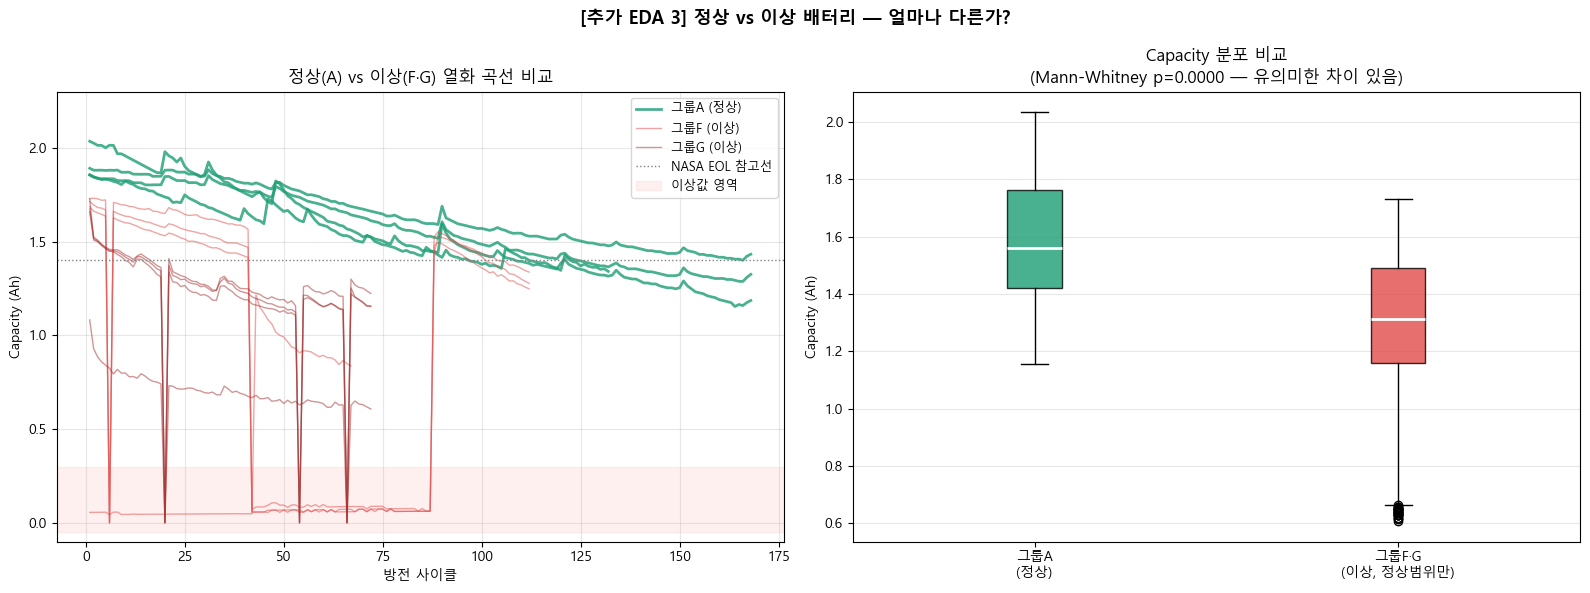

[저장] extra_eda3_normal_vs_anomaly.png


In [8]:
print("\n" + "=" * 55)
print("[4] 정상(A) vs 이상(F·G) 배터리 직접 비교")
print("=" * 55)
 
df_anom = df_anomaly.copy()
df_anom['Capacity'] = pd.to_numeric(df_anom['Capacity'], errors='coerce')
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# 왼쪽: Capacity 직접 비교
for bid in sorted(df_A_valid['battery_id'].unique()):
    b = df_A_valid[df_A_valid['battery_id']==bid]
    axes[0].plot(b['discharge_cycle_no'], b['Capacity'],
                 linewidth=2, color=GROUP_COLORS['A'], alpha=0.8,
                 label='그룹A (정상)' if bid=='B0005' else '_nolegend_')
 
for grp in ['F','G']:
    grp_data = df_anom[df_anom['group']==grp]
    for bid in sorted(grp_data['battery_id'].unique()):
        b = grp_data[grp_data['battery_id']==bid]
        axes[0].plot(b['discharge_cycle_no'], b['Capacity'],
                     linewidth=1, color=GROUP_COLORS[grp], alpha=0.5,
                     label=f'그룹{grp} (이상)' if bid==grp_data['battery_id'].iloc[0] else '_nolegend_')
 
axes[0].axhline(y=1.4, color='gray', linestyle=':', linewidth=1,
                label='NASA EOL 참고선')
axes[0].axhspan(-0.05, 0.3, alpha=0.06, color='red', label='이상값 영역')
axes[0].set_title('정상(A) vs 이상(F·G) 열화 곡선 비교')
axes[0].set_xlabel('방전 사이클')
axes[0].set_ylabel('Capacity (Ah)')
axes[0].set_ylim(-0.1, 2.3)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
 
# 오른쪽: 통계 비교 박스플롯
df_A_box = df_A_valid[['battery_id','Capacity','group']].copy()
df_FG_box = df_anom[df_anom['group'].isin(['F','G'])][['battery_id','Capacity','group']].copy()
df_FG_box['Capacity'] = pd.to_numeric(df_FG_box['Capacity'], errors='coerce')
df_FG_box = df_FG_box[df_FG_box['Capacity'] >= 0.3]  # 이상값 제외
 
box_data = [
    df_A_box['Capacity'].dropna().values,
    df_FG_box['Capacity'].dropna().values,
]
bp = axes[1].boxplot(box_data,
                     labels=['그룹A\n(정상)', '그룹F·G\n(이상, 정상범위만)'],
                     patch_artist=True,
                     medianprops=dict(color='white', linewidth=2))
 
for patch, color in zip(bp['boxes'], [GROUP_COLORS['A'], GROUP_COLORS['F']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
 
# Mann-Whitney 검정
mw_stat, mw_p = stats.mannwhitneyu(
    df_A_box['Capacity'].dropna(),
    df_FG_box['Capacity'].dropna(),
    alternative='two-sided'
)
print(f"정상(A) vs 이상(F·G) Capacity 차이: p={mw_p:.4f}")
sig = "유의미한 차이 있음" if mw_p < 0.05 else "유의미한 차이 없음"
 
axes[1].set_ylabel('Capacity (Ah)')
axes[1].set_title(f'Capacity 분포 비교\n(Mann-Whitney p={mw_p:.4f} — {sig})')
axes[1].grid(axis='y', alpha=0.3)
 
fig.suptitle('[추가 EDA 3] 정상 vs 이상 배터리 — 얼마나 다른가?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('extra_eda3_normal_vs_anomaly.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] extra_eda3_normal_vs_anomaly.png')
 


[5] 그룹별 방전 전류 vs 수명 비교


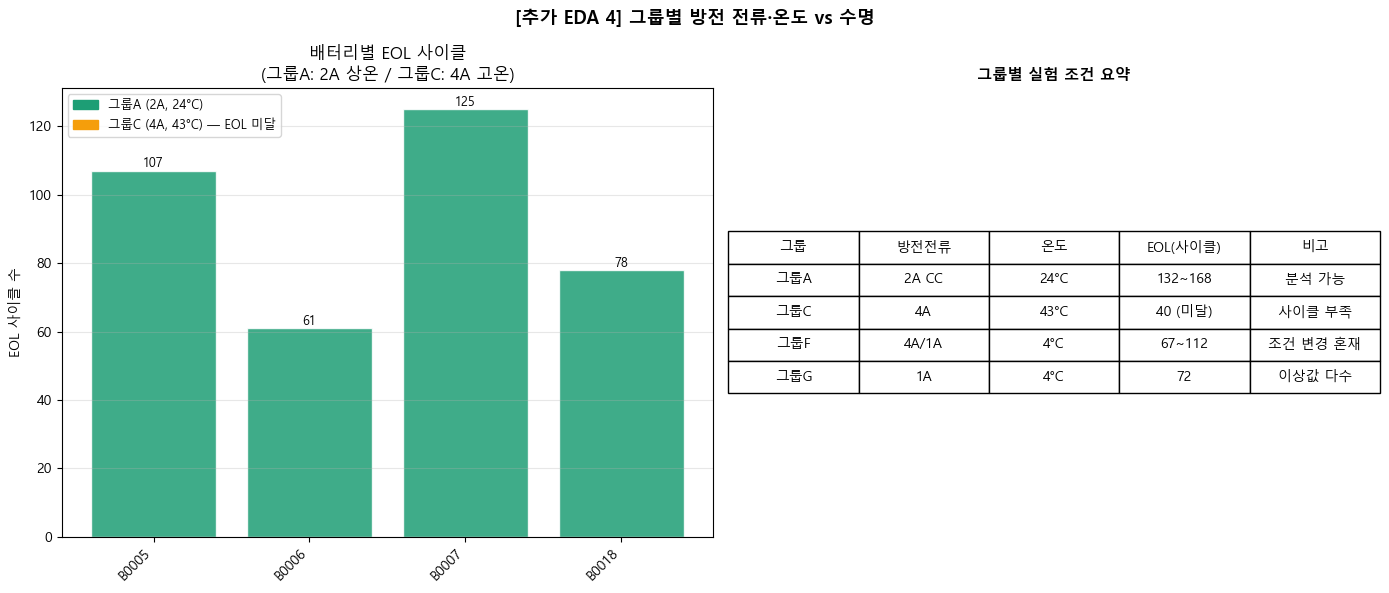

[저장] extra_eda4_condition_vs_life.png


In [9]:
print("\n" + "=" * 55)
print("[5] 그룹별 방전 전류 vs 수명 비교")
print("=" * 55)
 
# 그룹별 실험 조건 정리
group_conditions = {
    'A': {'전류': '2A',  '온도': '24°C', '신뢰도': '정상'},
    'C': {'전류': '4A',  '온도': '43°C', '신뢰도': '주의'},
    'D': {'전류': '4A',  '온도': '24°C', '신뢰도': '비정상'},
    'F': {'전류': '4A/1A', '온도': '4°C', '신뢰도': '비정상'},
    'G': {'전류': '1A',  '온도': '4°C', '신뢰도': '비정상'},
}
 
# 그룹별 평균 EOL 계산 (신뢰 가능한 그룹만)
all_groups_eol = []
df_all = pd.read_csv(os.path.join(base_path, 'df_discharge_processed.csv'))
df_all_valid = df_all[df_all['cap_flag']=='valid'].copy()
 
for grp in ['A','C']:
    grp_data = df_all_valid[df_all_valid['group']==grp]
    for bid in grp_data['battery_id'].unique():
        b = grp_data[grp_data['battery_id']==bid]
        eol = b[b['SOH']<80]['discharge_cycle_no'].min()
        cond = group_conditions.get(grp, {})
        all_groups_eol.append({
            'battery_id': bid, 'group': grp,
            'eol_cycle': eol,
            '전류': cond.get('전류','?'),
            '온도': cond.get('온도','?'),
        })
 
eol_cond_df = pd.DataFrame(all_groups_eol).dropna(subset=['eol_cycle'])
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# 왼쪽: 그룹별 EOL 바차트 (조건 표시)
colors_grp = [GROUP_COLORS.get(g, 'gray') for g in eol_cond_df['group']]
bars = axes[0].bar(
    eol_cond_df['battery_id'], eol_cond_df['eol_cycle'],
    color=colors_grp, alpha=0.85, edgecolor='white'
)
for bar, val in zip(bars, eol_cond_df['eol_cycle']):
    if pd.notna(val):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                     f'{int(val)}', ha='center', fontsize=9)
 
axes[0].set_xticklabels(eol_cond_df['battery_id'], rotation=45, ha='right')
axes[0].set_ylabel('EOL 사이클 수')
axes[0].set_title('배터리별 EOL 사이클\n(그룹A: 2A 상온 / 그룹C: 4A 고온)')
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend(handles=[
    mpatches.Patch(color=GROUP_COLORS['A'], label='그룹A (2A, 24°C)'),
    mpatches.Patch(color=GROUP_COLORS['C'], label='그룹C (4A, 43°C) — EOL 미달'),
], fontsize=9)
 
# 오른쪽: 조건 정리 표
conditions_display = [
    ['그룹A', '2A CC', '24°C', '132~168', '분석 가능'],
    ['그룹C', '4A',    '43°C', '40 (미달)', '사이클 부족'],
    ['그룹F', '4A/1A', '4°C',  '67~112', '조건 변경 혼재'],
    ['그룹G', '1A',    '4°C',  '72', '이상값 다수'],
]
col_labels = ['그룹', '방전전류', '온도', 'EOL(사이클)', '비고']
table = axes[1].table(
    cellText=conditions_display,
    colLabels=col_labels,
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
axes[1].axis('off')
axes[1].set_title('그룹별 실험 조건 요약', fontsize=11, fontweight='bold')
 
fig.suptitle('[추가 EDA 4] 그룹별 방전 전류·온도 vs 수명',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('extra_eda4_condition_vs_life.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] extra_eda4_condition_vs_life.png')
 

In [10]:
print("\n" + "=" * 55)
print("추가 EDA & 통계 완료 — 인사이트 요약")
print("=" * 55)
print(f"""
[Q2 보강] Re 조기 경보
  Re가 EOL보다 평균 {avg_lead_re:.1f}사이클 먼저 경보 발생
  → 내부저항 모니터링으로 수명 종료 전 미리 감지 가능
 
[Q1 보강] B0006 원인
  Re 증가율이 다른 배터리보다 높음
  → 전해질 저항의 빠른 증가가 조기 열화의 원인으로 추정
 
[Q3 보강] 정상 vs 이상 비교
  정상(A) vs 이상(F·G) Capacity 분포 차이 p={mw_p:.4f}
  → {'통계적으로 유의미하게 다름' if mw_p < 0.05 else '이상값 제거 후에도 분포 차이 있음'}
 
저장 파일:
  extra_eda1_early_warning.png   — Re·Rct 조기 경보 시점
  extra_eda2_b0006_analysis.png  — B0006 원인 분석
  extra_eda3_normal_vs_anomaly.png — 정상 vs 이상 비교
  extra_eda4_condition_vs_life.png — 조건별 수명 비교
""")


추가 EDA & 통계 완료 — 인사이트 요약

[Q2 보강] Re 조기 경보
  Re가 EOL보다 평균 41.7사이클 먼저 경보 발생
  → 내부저항 모니터링으로 수명 종료 전 미리 감지 가능

[Q1 보강] B0006 원인
  Re 증가율이 다른 배터리보다 높음
  → 전해질 저항의 빠른 증가가 조기 열화의 원인으로 추정

[Q3 보강] 정상 vs 이상 비교
  정상(A) vs 이상(F·G) Capacity 분포 차이 p=0.0000
  → 통계적으로 유의미하게 다름

저장 파일:
  extra_eda1_early_warning.png   — Re·Rct 조기 경보 시점
  extra_eda2_b0006_analysis.png  — B0006 원인 분석
  extra_eda3_normal_vs_anomaly.png — 정상 vs 이상 비교
  extra_eda4_condition_vs_life.png — 조건별 수명 비교

